In [ ]:
import pandas as pd
import numpy as np

In [1]:
import os
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
knowledge = pd.read_csv('User Knowledge.csv')
knowledge.head()

,STG,SCG,STR,LPR,PEG
0,0.00,0.00,0.00,0.00,0.00
1,0.08,0.08,0.10,0.24,0.90
2,0.06,0.06,0.05,0.25,0.33
3,0.10,0.10,0.15,0.65,0.30
4,0.08,0.08,0.08,0.98,0.24


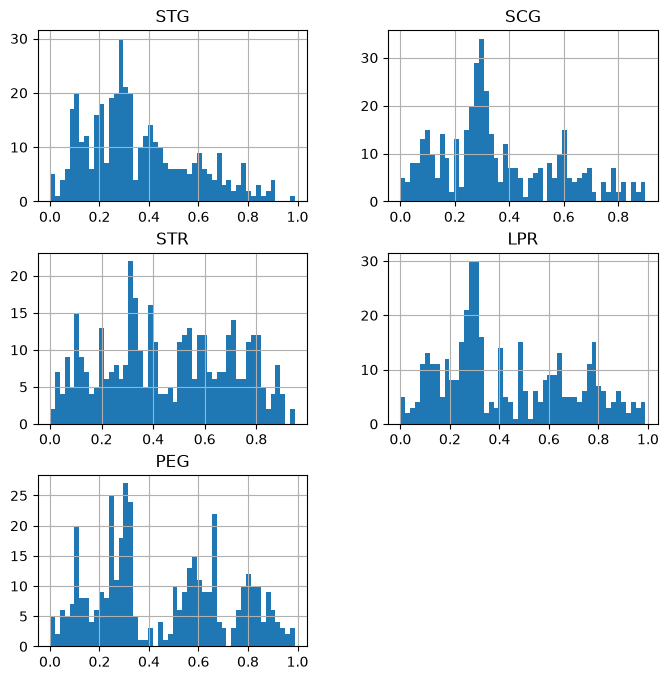

In [3]:
knowledge.hist(bins=50, figsize=(8,8))
plt.show()

In [4]:
import warnings
warnings.filterwarnings('ignore')

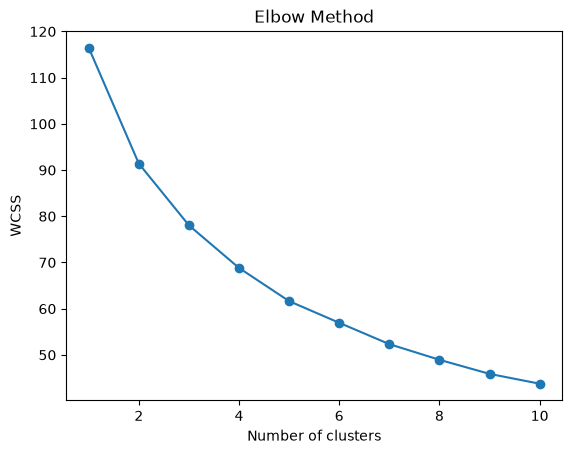

In [6]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=400, n_init=20, random_state=0)
    kmeans.fit(knowledge)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [9]:
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=400, n_init=20, random_state=0)
kmeans.fit(knowledge)
k_class = kmeans.predict(knowledge)

In [10]:
k_class

array([2, 1, 2, 2, 0, 1, 1, 2, 0, 1, 1, 2, 0, 1, 1, 1, 2, 2, 2, 2, 0, 1,
       1, 2, 0, 1, 2, 2, 0, 1, 1, 0, 0, 1, 1, 2, 0, 2, 2, 2, 0, 1, 1, 0,
       2, 1, 1, 1, 1, 1, 2, 0, 0, 1, 1, 2, 0, 1, 1, 0, 0, 1, 1, 0, 0, 2,
       2, 2, 2, 1, 1, 1, 2, 1, 1, 2, 0, 2, 2, 0, 0, 1, 1, 2, 2, 2, 1, 2,
       0, 1, 1, 0, 0, 2, 1, 0, 0, 1, 1, 2, 2, 1, 1, 2, 0, 1, 1, 1, 0, 1,
       2, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 2, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       2, 0, 1, 2, 2, 0, 1, 2, 2, 0, 1, 2, 0, 0, 2, 2, 2, 0, 1, 2, 2, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 0, 1, 2,
       0, 0, 1, 1, 0, 0, 1, 2, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 2, 2, 0,
       1, 2, 2, 0, 2, 2, 0, 0, 1, 1, 2, 0, 1, 2, 1, 0, 1, 2, 2, 0, 1, 2,
       0, 0, 1, 1, 0, 0, 1, 2, 1, 0, 1, 2, 0, 0, 1, 2, 0, 1, 1, 1, 0, 0,
       1, 2, 0, 0, 1, 2, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 2, 2, 1, 1, 1, 2,
       0, 0, 0, 2, 1, 2, 1, 0, 1, 2, 0, 2, 2, 1, 1, 0, 0, 2, 1, 2, 2, 0,
       0, 2, 2, 2, 0, 0, 2, 1, 0, 0, 1, 1, 2, 2, 0,

In [11]:
pca = PCA(n_components=3)
principalComponents = pca.fit_transform(knowledge)
PDF = pd.DataFrame(data=principalComponents, columns = ['PC1','PC2','PC3'])
PDF

,PC1,PC2,PC3
0,-0.851933,-0.320158,0.008387
1,-0.020553,-0.446032,-0.218312
2,-0.487168,-0.215345,-0.116477
3,-0.354270,0.175159,-0.140726
4,-0.368738,0.480435,-0.250391
...,...,...,...
398,0.656978,-0.187663,-0.209717
399,0.743754,0.300973,-0.257781
400,0.098946,-0.131658,0.255435
401,0.457211,0.177232,0.077876


In [15]:
PDF['Cluster'] = k_class
knowledge_class = knowledge.copy()
knowledge_class['Class'] = k_class
PDF

,PC1,PC2,PC3,Cluster
0,-0.851933,-0.320158,0.008387,2
1,-0.020553,-0.446032,-0.218312,1
2,-0.487168,-0.215345,-0.116477,2
3,-0.354270,0.175159,-0.140726,2
4,-0.368738,0.480435,-0.250391,0
...,...,...,...,...
398,0.656978,-0.187663,-0.209717,1
399,0.743754,0.300973,-0.257781,0
400,0.098946,-0.131658,0.255435,1
401,0.457211,0.177232,0.077876,0


In [16]:
knowledge_class

,STG,SCG,STR,LPR,PEG,Class
0,0.00,0.00,0.00,0.00,0.00,2
1,0.08,0.08,0.10,0.24,0.90,1
2,0.06,0.06,0.05,0.25,0.33,2
3,0.10,0.10,0.15,0.65,0.30,2
4,0.08,0.08,0.08,0.98,0.24,0
...,...,...,...,...,...,...
398,0.90,0.78,0.62,0.32,0.89,1
399,0.85,0.82,0.66,0.83,0.83,0
400,0.56,0.60,0.77,0.13,0.32,1
401,0.66,0.68,0.81,0.57,0.57,0


In [20]:
PDF['Cluster'].value_counts()

Cluster
1    146
2    130
0    127
Name: count, dtype: int64

In [21]:
PDF['Color'] = PDF['Cluster'].map({0:'red', 1:'blue', 2:'green'})

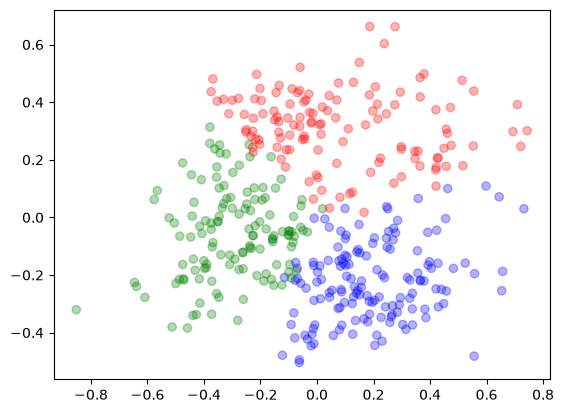

In [23]:
a1 = PDF['PC1']
a2 = PDF['PC2']
a3 = PDF['PC3']
c1 = PDF['Color']
plt.scatter(a1,a2,c=c1, alpha=0.3, cmap='viridis')

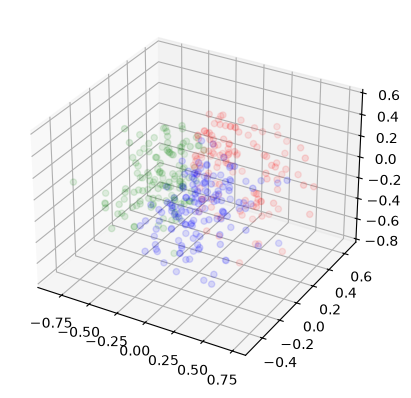

In [25]:
# 3-D plot of the data using 3 principal components
fig = plt.figure()
ax = Axes3D(fig)
ax = fig.add_subplot(111, projection='3d')  # Correct way to initialize 3D axis
ax.scatter(a1, a2, a3, alpha = 0.4, c = c1)

In [26]:
knowledge_class.groupby(['Class']).mean()

,STG,SCG,STR,LPR,PEG
Class,,,,,
0,0.380449,0.398882,0.512126,0.747087,0.409213
1,0.366438,0.397240,0.514212,0.276575,0.698425
2,0.311531,0.267608,0.340923,0.296700,0.230562


In [28]:
X = knowledge_class.iloc[:,:-1]
y = knowledge_class.iloc[:,-1]

xTrain, xTest, yTrain, yTest = train_test_split(X, y, test_size = 0.25, random_state = 0)

Text(0.5, 1.0, 'k v/s Accuracy for KNN')

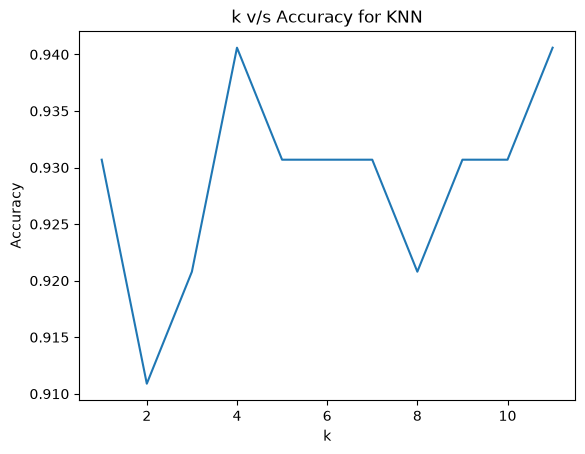

In [30]:
from sklearn.neighbors import KNeighborsClassifier
accuracy = []
for i in range(1,12):
    knn = KNeighborsClassifier(n_neighbors = i).fit(xTrain, yTrain)
    accuracy.append(knn.score(xTest, yTest))

plt.plot(range(1,12), accuracy)
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('k v/s Accuracy for KNN')

In [31]:
knn = KNeighborsClassifier(n_neighbors = accuracy.index(max(accuracy))+1).fit(xTrain, yTrain)
knn_predictions = knn.predict(xTest)
knn_accuracy = knn.score(xTest, yTest)
knn_accuracy

0.9405940594059405

In [32]:
knn_CM = confusion_matrix(yTest, knn_predictions)
knn_CM

array([[30,  0,  0],
       [ 1, 37,  1],
       [ 3,  1, 28]])

In [33]:
# Decision Tree Classifier and evaluation for optimal value of k
from sklearn.tree import DecisionTreeClassifier
dtree_model = DecisionTreeClassifier(max_depth = 2).fit(xTrain, yTrain) 
dtree_predictions = dtree_model.predict(xTest)
dt_accuracy = dtree_model.score(xTest, yTest)
dt_accuracy

0.9405940594059405

In [34]:
DT_CM = confusion_matrix(yTest, dtree_predictions)
DT_CM

array([[29,  1,  0],
       [ 1, 37,  1],
       [ 2,  1, 29]])

In [35]:
# Gaussian Naive Bayes model and evaluation for optimal value of k
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB().fit(xTrain, yTrain)
gnb_predictions = gnb.predict(xTest)
gnb_accuracy = gnb.score(xTest, yTest)
gnb_accuracy

0.9603960396039604

In [36]:
NB_CM = confusion_matrix(yTest, gnb_predictions) # Naive Bayes confusion Matrix
NB_CM

array([[29,  1,  0],
       [ 1, 37,  1],
       [ 0,  1, 31]])